# Literature Review: E-commerce Churn Analysis

E-commerce churn tab hota hai jab customer platform use karna band kar deta hai. Research ke according churn dheere-dheere develop hota hai, sudden nahi hota.

Churn ka main reason hota hai customer ka behavior change hona.

## Key Factors:
- Low engagement aur browsing activity
- Long time se purchase na karna (recency high hona)
- Low satisfaction aur poor experience
- High return rate aur support complaints
- High price sensitivity aur discount dependency
- Low purchase history (low orders & spending)
- High cart abandonment

## Business Impact:
In factors ki wajah se revenue aur customer lifetime value (CLV) dono decrease hote hain. Loyal customers company ke growth ke liye most important hote hain.

## Data Science View:
Recency, engagement score, satisfaction score aur service-related features churn prediction ke strongest signals hote hain. Machine learning models in patterns ko use karke churn predict karte hain.

## Final Insight:
Churn mainly 5 cheezon se hota hai: low engagement, inactivity, poor satisfaction, service issues aur price sensitivity. Growth tab hoti hai jab customer experience aur engagement improve kiya jaye.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\Users\nehak\OneDrive\Desktop\e commerce.csv')
df

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,7e6f01d6-a7bb-429e-91d1-7c929547852b,2,77.48,1,22,0.066,0.0056,1,No,7.6,0.773,4.55,6.47,8.86,3.0,No
5996,4874448f-192d-4c5a-a21b-80d02b70c0e4,52,49.06,27,23,0.135,0.0224,0,No,1.1,0.863,5.00,5.12,9.93,3.7,No
5997,6a5b9ad3-7488-40e9-95b7-ad0ea7354f51,8,66.12,1,14,0.127,0.0352,0,No,1.5,0.732,3.23,4.83,8.11,3.5,No
5998,3306b81f-13df-4ae9-947d-deaaf7723279,4,103.95,3,1,0.231,0.0288,0,No,1.7,0.509,5.00,5.62,9.90,4.0,No


In [3]:
df.columns

Index(['Customer_ID', 'account_age_months', 'avg_order_value', 'total_orders',
       'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
       'customer_support_tickets', 'loyalty_member',
       'browsing_frequency_per_week', 'cart_abandonment_rate',
       'product_review_score_avg', 'engagement_score', 'satisfaction_score',
       'price_sensitivity_index', 'churned'],
      dtype='object')

In [4]:
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


In [5]:
df.tail()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
5995,7e6f01d6-a7bb-429e-91d1-7c929547852b,2,77.48,1,22,0.066,0.0056,1,No,7.6,0.773,4.55,6.47,8.86,3.0,No
5996,4874448f-192d-4c5a-a21b-80d02b70c0e4,52,49.06,27,23,0.135,0.0224,0,No,1.1,0.863,5.00,5.12,9.93,3.7,No
5997,6a5b9ad3-7488-40e9-95b7-ad0ea7354f51,8,66.12,1,14,0.127,0.0352,0,No,1.5,0.732,3.23,4.83,8.11,3.5,No
5998,3306b81f-13df-4ae9-947d-deaaf7723279,4,103.95,3,1,0.231,0.0288,0,No,1.7,0.509,5.00,5.62,9.90,4.0,No
5999,48867913-4bb5-4823-87f0-dd405e3970e4,9,35.17,1,24,0.664,0.0968,1,No,1.3,0.935,4.17,4.27,8.18,7.4,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [7]:
df['churned'].value_counts()

churned
No     5071
Yes     929
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Customer_ID                    0
account_age_months             0
avg_order_value                0
total_orders                   0
days_since_last_purchase       0
discount_usage_rate            0
return_rate                    0
customer_support_tickets       0
loyalty_member                 0
browsing_frequency_per_week    0
cart_abandonment_rate          0
product_review_score_avg       0
engagement_score               0
satisfaction_score             0
price_sensitivity_index        0
churned                        0
dtype: int64

In [9]:
df=df.dropna()

##### Checking duplicated

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop('Customer_ID', axis=1)

In [12]:
df.head()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


#### Univariate Analysis

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['account_age_months', 'avg_order_value', 'total_orders',
       'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
       'customer_support_tickets', 'browsing_frequency_per_week',
       'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score',
       'satisfaction_score', 'price_sensitivity_index'],
      dtype='object')

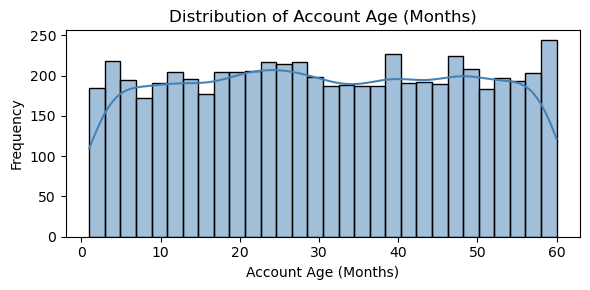

In [14]:
plt.figure(figsize=(6, 3))
sns.histplot(df['account_age_months'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Account Age (Months)')
plt.xlabel('Account Age (Months)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

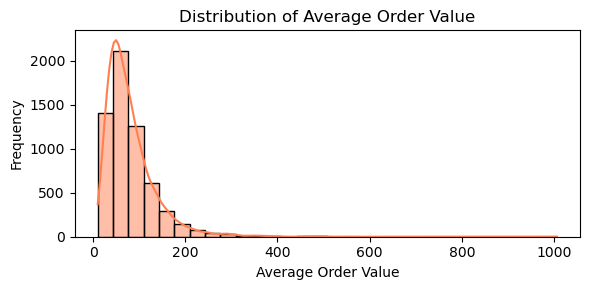

In [15]:
plt.figure(figsize=(6, 3))
sns.histplot(df['avg_order_value'], bins=30, kde=True, color='coral')
plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

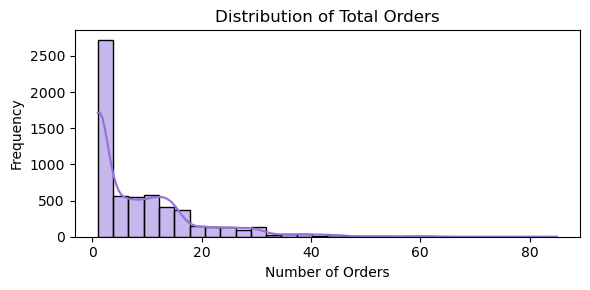

In [16]:
plt.figure(figsize=(6, 3))
sns.histplot(df['total_orders'], bins=30, kde=True, color='mediumpurple')
plt.title('Distribution of Total Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

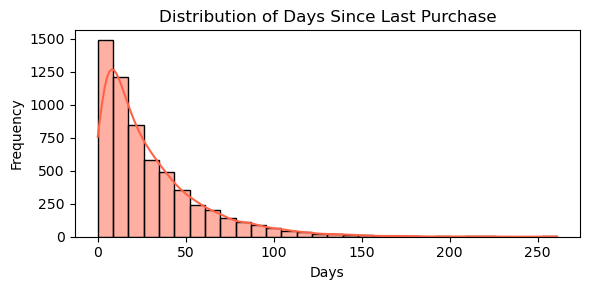

In [17]:
plt.figure(figsize=(6, 3))
sns.histplot(df['days_since_last_purchase'], bins=30, kde=True, color='tomato')
plt.title('Distribution of Days Since Last Purchase')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

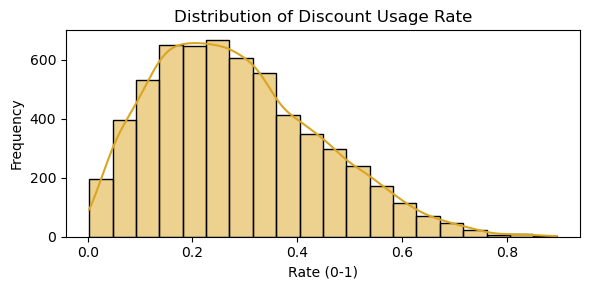

In [18]:
plt.figure(figsize=(6, 3))
sns.histplot(df['discount_usage_rate'], bins=20, kde=True, color='goldenrod')
plt.title('Distribution of Discount Usage Rate')
plt.xlabel('Rate (0-1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

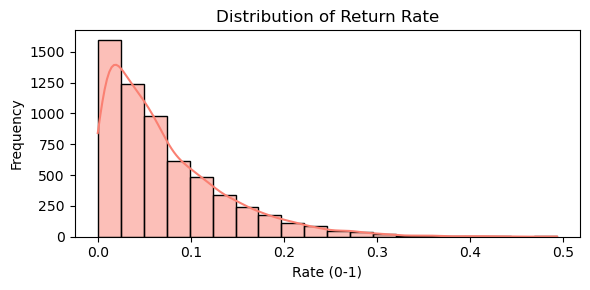

In [19]:
plt.figure(figsize=(6, 3))
sns.histplot(df['return_rate'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Return Rate')
plt.xlabel('Rate (0-1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

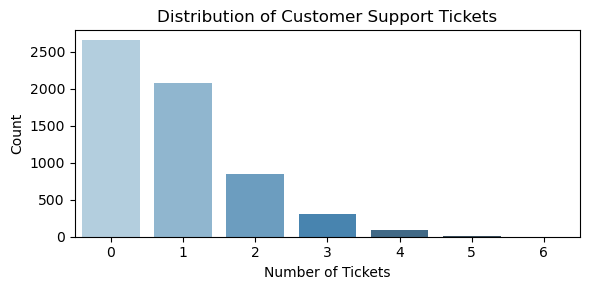

In [20]:
plt.figure(figsize=(6, 3))
sns.countplot(x='customer_support_tickets', data=df,
              hue='customer_support_tickets',
              palette='Blues_d',
              order=sorted(df['customer_support_tickets'].unique()),
              legend=False)
plt.title('Distribution of Customer Support Tickets')
plt.xlabel('Number of Tickets')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

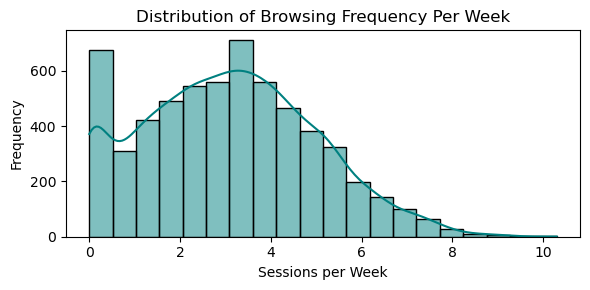

In [21]:
plt.figure(figsize=(6, 3))
sns.histplot(df['browsing_frequency_per_week'], bins=20, kde=True, color='teal')
plt.title('Distribution of Browsing Frequency Per Week')
plt.xlabel('Sessions per Week')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

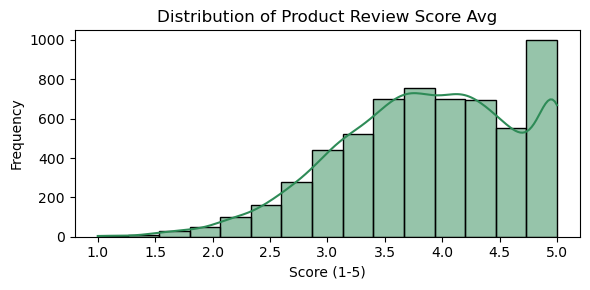

In [22]:
plt.figure(figsize=(6, 3))
sns.histplot(df['product_review_score_avg'], bins=15, kde=True, color='seagreen')
plt.title('Distribution of Product Review Score Avg')
plt.xlabel('Score (1-5)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

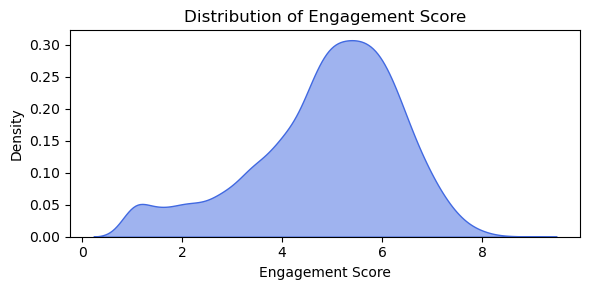

In [23]:
plt.figure(figsize=(6, 3))
sns.kdeplot(df['engagement_score'], fill=True, color='royalblue', alpha=0.5)
plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

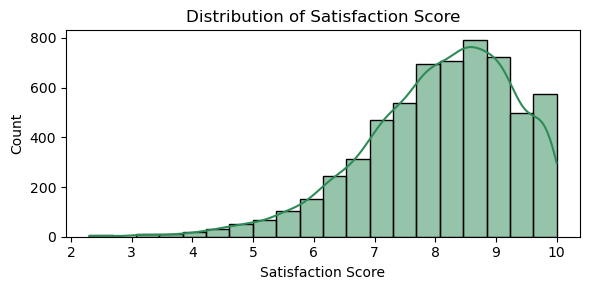

In [24]:
plt.figure(figsize=(6, 3))
sns.histplot(df['satisfaction_score'], bins=20, kde=True, color='seagreen')
plt.title('Distribution of Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

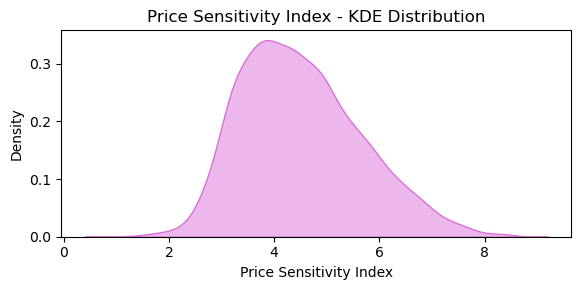

In [25]:
plt.figure(figsize=(6, 3))
sns.kdeplot(df['price_sensitivity_index'], fill=True, color='orchid', alpha=0.5)
plt.title('Price Sensitivity Index - KDE Distribution')
plt.xlabel('Price Sensitivity Index')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   account_age_months           6000 non-null   int64  
 1   avg_order_value              6000 non-null   float64
 2   total_orders                 6000 non-null   int64  
 3   days_since_last_purchase     6000 non-null   int64  
 4   discount_usage_rate          6000 non-null   float64
 5   return_rate                  6000 non-null   float64
 6   customer_support_tickets     6000 non-null   int64  
 7   loyalty_member               6000 non-null   object 
 8   browsing_frequency_per_week  6000 non-null   float64
 9   cart_abandonment_rate        6000 non-null   float64
 10  product_review_score_avg     6000 non-null   float64
 11  engagement_score             6000 non-null   float64
 12  satisfaction_score           6000 non-null   float64
 13  price_sensitivity_

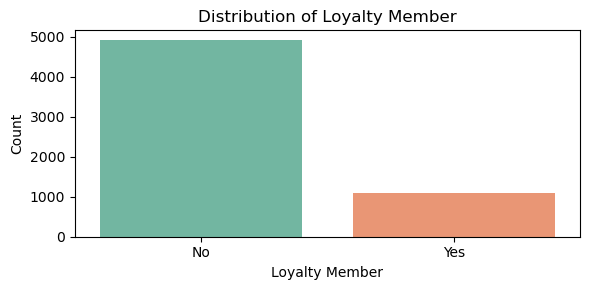

In [27]:
# categorical column
# loyalty_member
plt.figure(figsize=(6, 3))
sns.countplot(x='loyalty_member', data=df,
              hue='loyalty_member',
              palette='Set2',
              legend=False)
plt.title('Distribution of Loyalty Member')
plt.xlabel('Loyalty Member')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

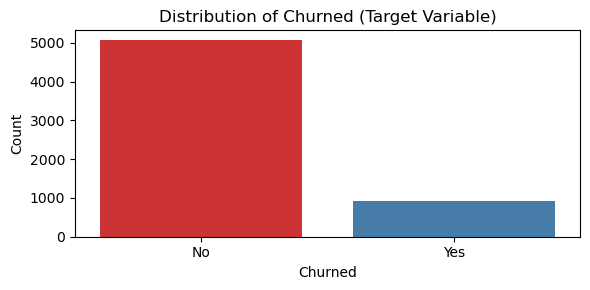

In [28]:
# churned
plt.figure(figsize=(6, 3))
sns.countplot(x='churned', data=df,
              hue='churned',
              palette='Set1',
              legend=False)
plt.title('Distribution of Churned (Target Variable)')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Bivariate Analysis 

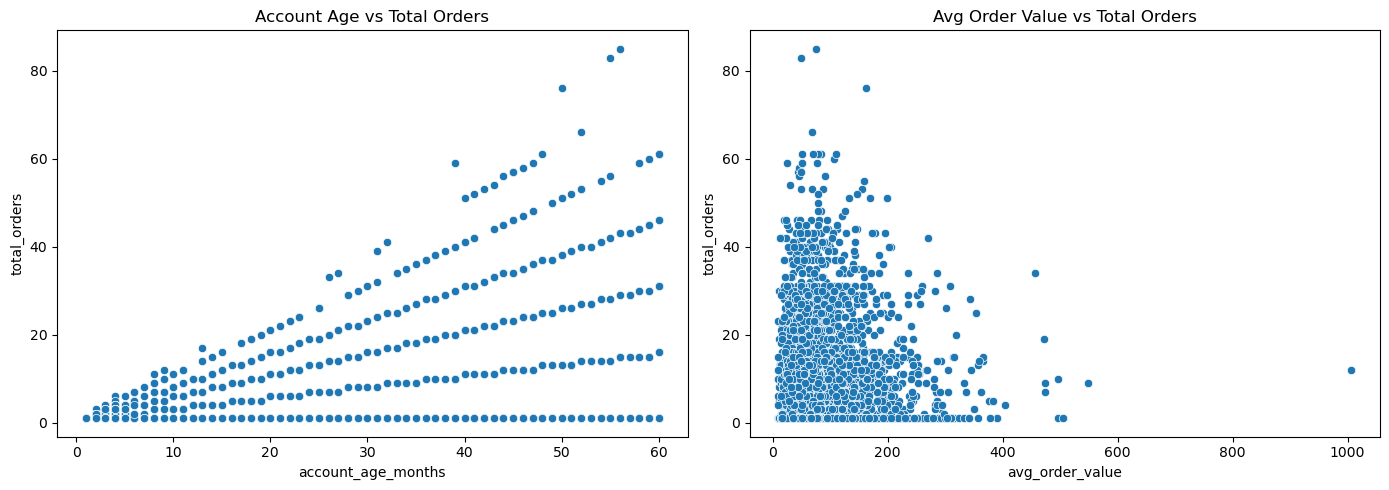

In [29]:
# account_age_months
fig, axes = plt.subplots(1,2 ,figsize=(14, 5))

sns.scatterplot(x='account_age_months', y='total_orders', data=df, ax=axes[0])
axes[0].set_title("Account Age vs Total Orders")
# avg_order_value
sns.scatterplot(x='avg_order_value', y='total_orders', data=df, ax=axes[1])
axes[1].set_title("Avg Order Value vs Total Orders")

plt.tight_layout()
plt.show()

Insights:

1.According to the graph_1  total_orders are increasing gradually as per account_age_months.

2.According to the graph_2  total_orders are very high in between 0 to 400   as per avg_order_value.

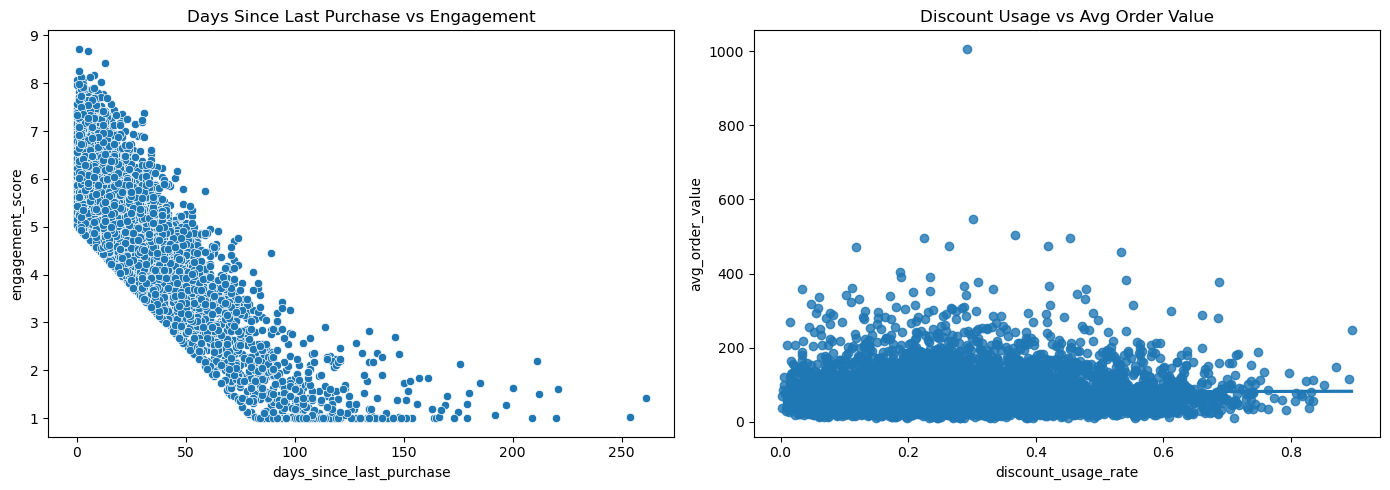

In [30]:
# days_since_last_purchase 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='days_since_last_purchase', y='engagement_score', data=df, ax=axes[0])
axes[0].set_title("Days Since Last Purchase vs Engagement")
# discount_usage_rate
sns.regplot(x='discount_usage_rate', y='avg_order_value', data=df, ax=axes[1])
axes[1].set_title("Discount Usage vs Avg Order Value")

plt.tight_layout()
plt.show()

Insights:

1.According to the graph_1   Customers who stop purchasing become less engaged.

2.According to the graph_2  while discount behavior strongly influences spending patterns and profitability.

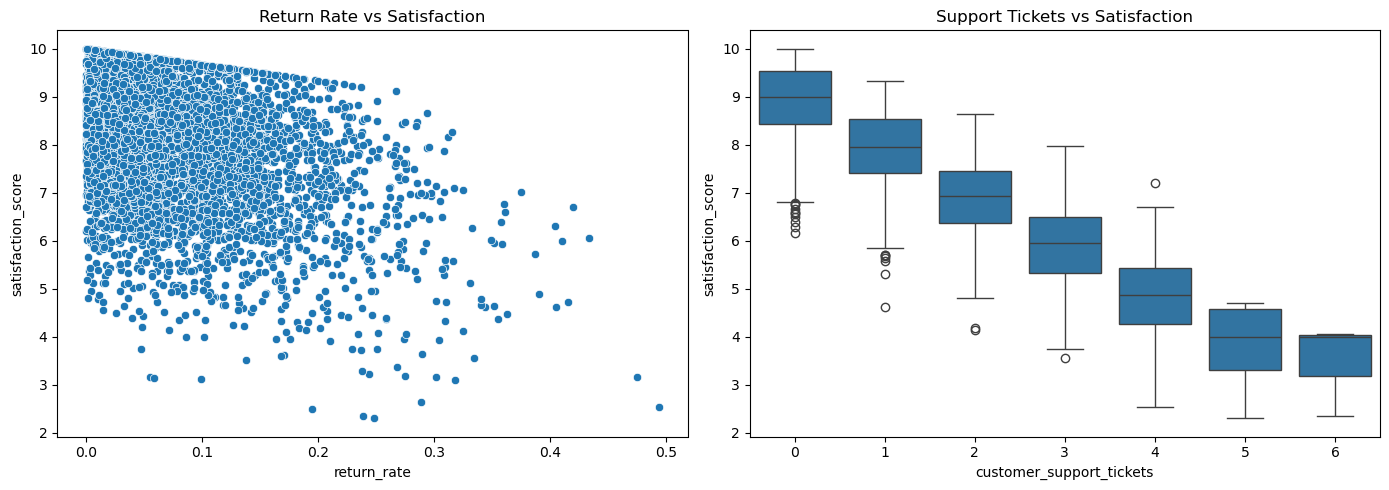

In [31]:
# return_rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='return_rate', y='satisfaction_score', data=df, ax=axes[0])
axes[0].set_title("Return Rate vs Satisfaction")

# customer_support_tickets
sns.boxplot(x='customer_support_tickets', y='satisfaction_score', data=df, ax=axes[1])
axes[1].set_title("Support Tickets vs Satisfaction")

plt.tight_layout()
plt.show()

Insights:

According to the above graphs Customers with higher return rates and more support tickets tend to have lower satisfaction, indicating product and service quality directly affect customer retention and loyalty.

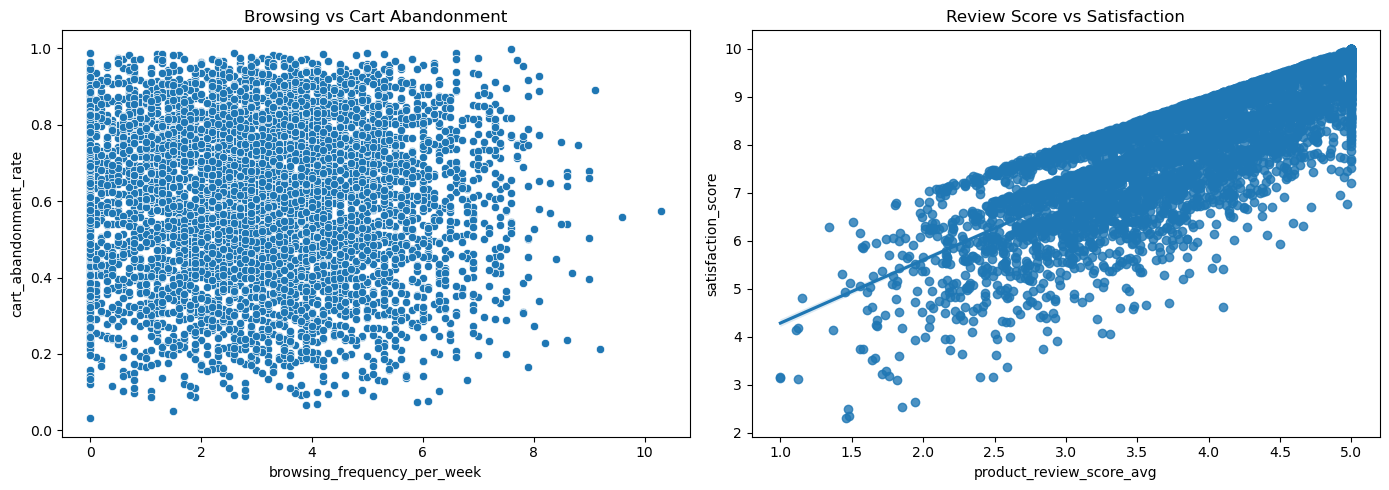

In [32]:
# browsing_frequency_per_week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='browsing_frequency_per_week', y='cart_abandonment_rate', data=df, ax=axes[0])
axes[0].set_title("Browsing vs Cart Abandonment")

# product_review_score_avg
sns.regplot(x='product_review_score_avg', y='satisfaction_score', data=df, ax=axes[1])
axes[1].set_title("Review Score vs Satisfaction")

plt.tight_layout()
plt.show()

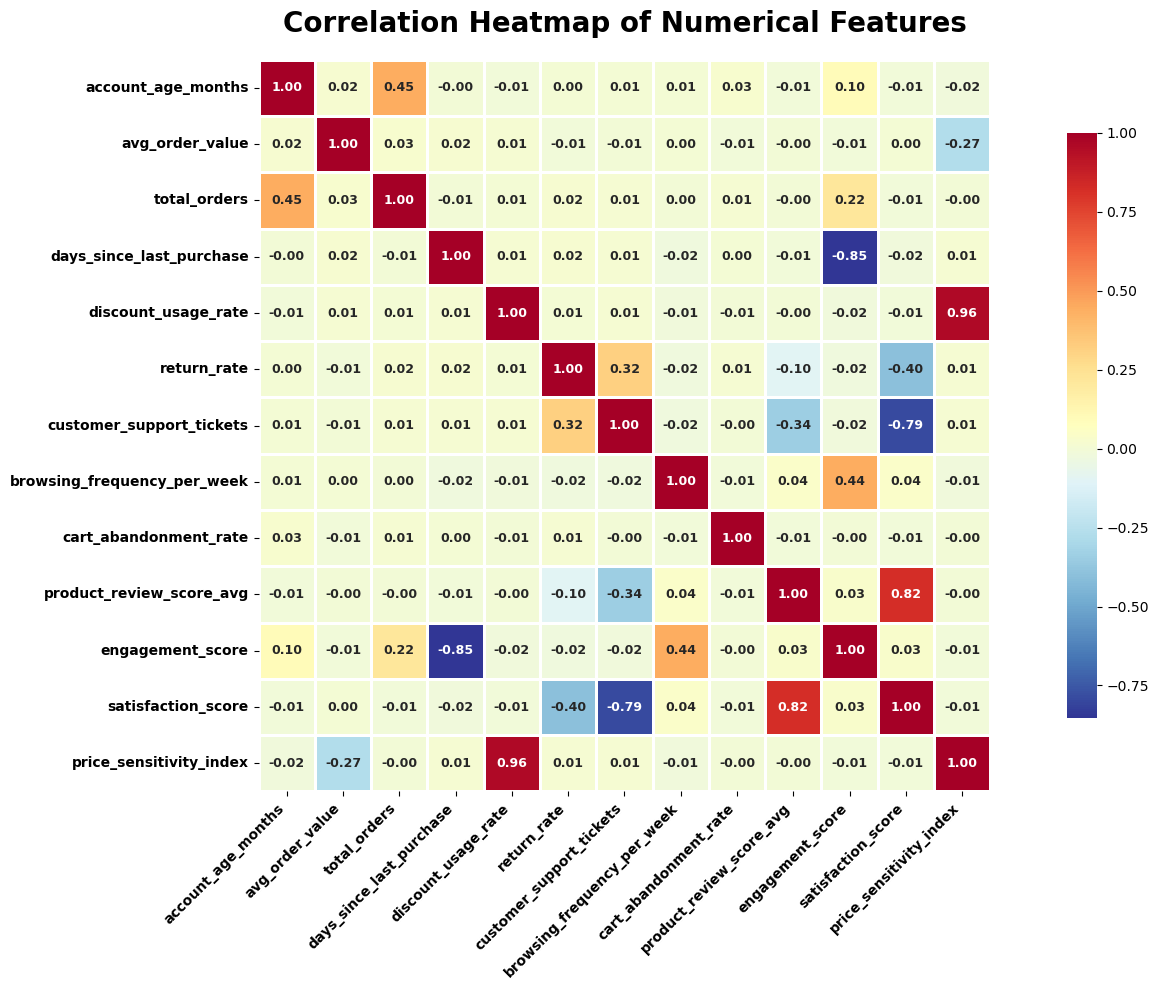

In [33]:
# Correlation matrix
corr_matrix = df[num_cols].corr()

# Heatmap Styling
plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    linewidths=1,
    linecolor='white',
    square=True,
    cbar_kws={'shrink':0.8},
    annot_kws={'size':9, 'weight':'bold'}
)

# Title Styling
plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=20,
    fontweight='bold',
    pad=20
)

# Tick Styling
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10,
    fontweight='bold'
)

plt.yticks(
    rotation=0,
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

Insides:-

The correlation heatmap reveals that customer engagement, satisfaction, purchasing behavior, returns, and support experience are strongly interconnected and directly impact customer retention and business profitability.

### PATTERN 1:  Silent Friction (High Engagement + Low Satisfaction)

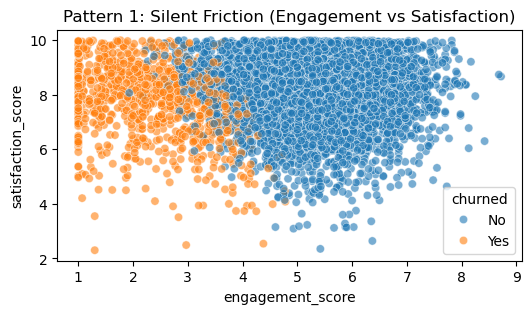

In [34]:
plt.figure(figsize=(6,3))

sns.scatterplot(
    x='engagement_score',
    y='satisfaction_score',
    hue='churned',
    data=df,
    alpha=0.6
)

plt.title("Pattern 1: Silent Friction (Engagement vs Satisfaction)")
plt.show()

Insides

Customers with high engagement and satisfaction are more loyal, while low engagement and low satisfaction strongly indicate churn risk; highly engaged but dissatisfied customers reveal hidden frustration that may lead to future churn.

### PATTERN 2: Browse Trap (High Browsing, Low Orders)

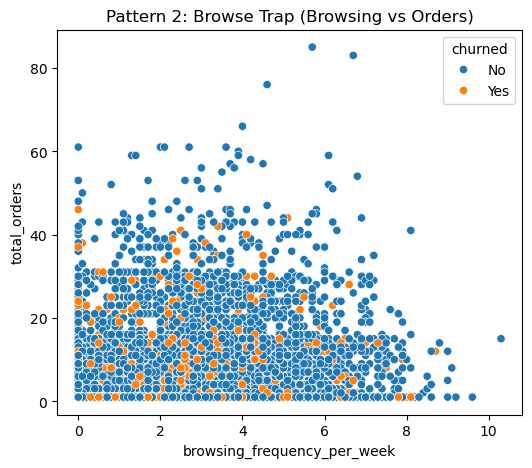

In [35]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x='browsing_frequency_per_week',
    y='total_orders',
    hue='churned',
    data=df
)

plt.title("Pattern 2: Browse Trap (Browsing vs Orders)")
plt.show()

Insides:

The graph reveals that many customers browse frequently without purchasing, indicating a “Browse Trap” where user interest exists but conversion barriers prevent sales and may eventually lead to churn.

### PATTERN 3: Support Paradox (High support but not always churn)

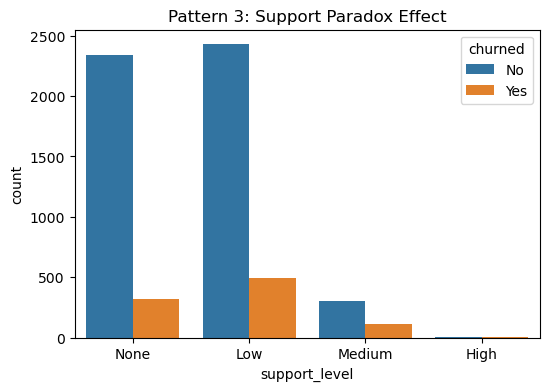

In [36]:
df['support_level'] = pd.cut(df['customer_support_tickets'],
                             bins=[-1,0,2,5,10],
                             labels=['None','Low','Medium','High'])

plt.figure(figsize=(6,4))

sns.countplot(
    x='support_level',
    hue='churned',
    data=df
)

plt.title("Pattern 3: Support Paradox Effect")
plt.show()

Insides:

Customers with frequent support issues are more likely to churn, but effective customer service can recover dissatisfied users, creating the 'Support Paradox Effect'.

### PATTERN 4: Discount Addiction Loop

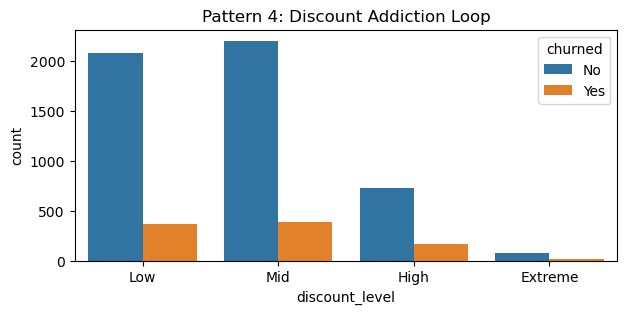

In [37]:
df['discount_level'] = pd.cut(df['discount_usage_rate'],
                               bins=4,
                               labels=['Low','Mid','High','Extreme'])

plt.figure(figsize=(7,3))

sns.countplot(
    x='discount_level',
    hue='churned',
    data=df
)

plt.title("Pattern 4: Discount Addiction Loop")
plt.show()

Insides:

The graph reveals that customers heavily dependent on discounts are more likely to churn, showing a “Discount Addiction Loop” where purchases are driven by offers rather than true customer loyalty.

### PATTERN 5: Slow Decay Churn (Time + Engagement drop)

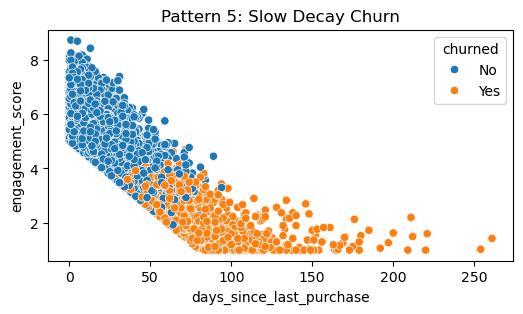

In [38]:
plt.figure(figsize=(6,3))

sns.scatterplot(
    x='days_since_last_purchase',
    y='engagement_score',
    hue='churned',
    data=df
)

plt.title("Pattern 5: Slow Decay Churn")
plt.show()

Insides:

The graph reveals that churn is usually a gradual process where customers slowly become inactive and less engaged over time before finally leaving the platform.

### PATTERN 6: False Loyalty Trap

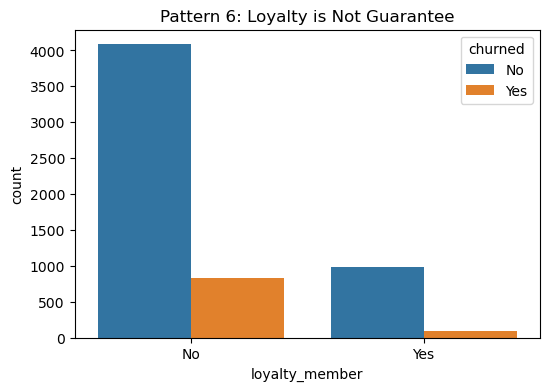

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='loyalty_member',
    hue='churned',
    data=df
)

plt.title("Pattern 6: Loyalty is Not Guarantee")
plt.show()

Insides:

The graph shows that loyalty programs improve retention, but loyalty membership alone cannot prevent churn if customers experience dissatisfaction, low engagement, or poor service quality.

### PATTERN 7: Price Sensitivity Amplifier

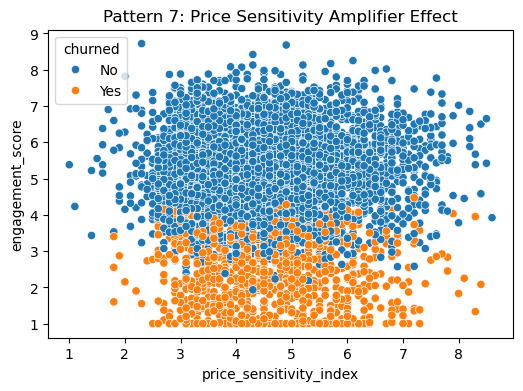

In [40]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='price_sensitivity_index',
    y='engagement_score',
    hue='churned',
    data=df
)

plt.title("Pattern 7: Price Sensitivity Amplifier Effect")
plt.show()

Insides:

The graph shows that highly price-sensitive customers are far more likely to churn when engagement drops, meaning price sensitivity amplifies customer instability and weak brand loyalty.

### PATTERN 8: Final Trigger (Satisfaction collapse)

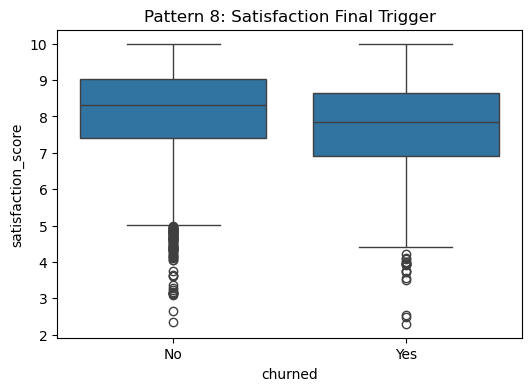

In [41]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x='churned',
    y='satisfaction_score',
    data=df
)

plt.title("Pattern 8: Satisfaction Final Trigger")
plt.show()

Insides:

The graph shows that low customer satisfaction is often the final trigger for churn, making satisfaction one of the strongest predictors of customer retention and loyalty.

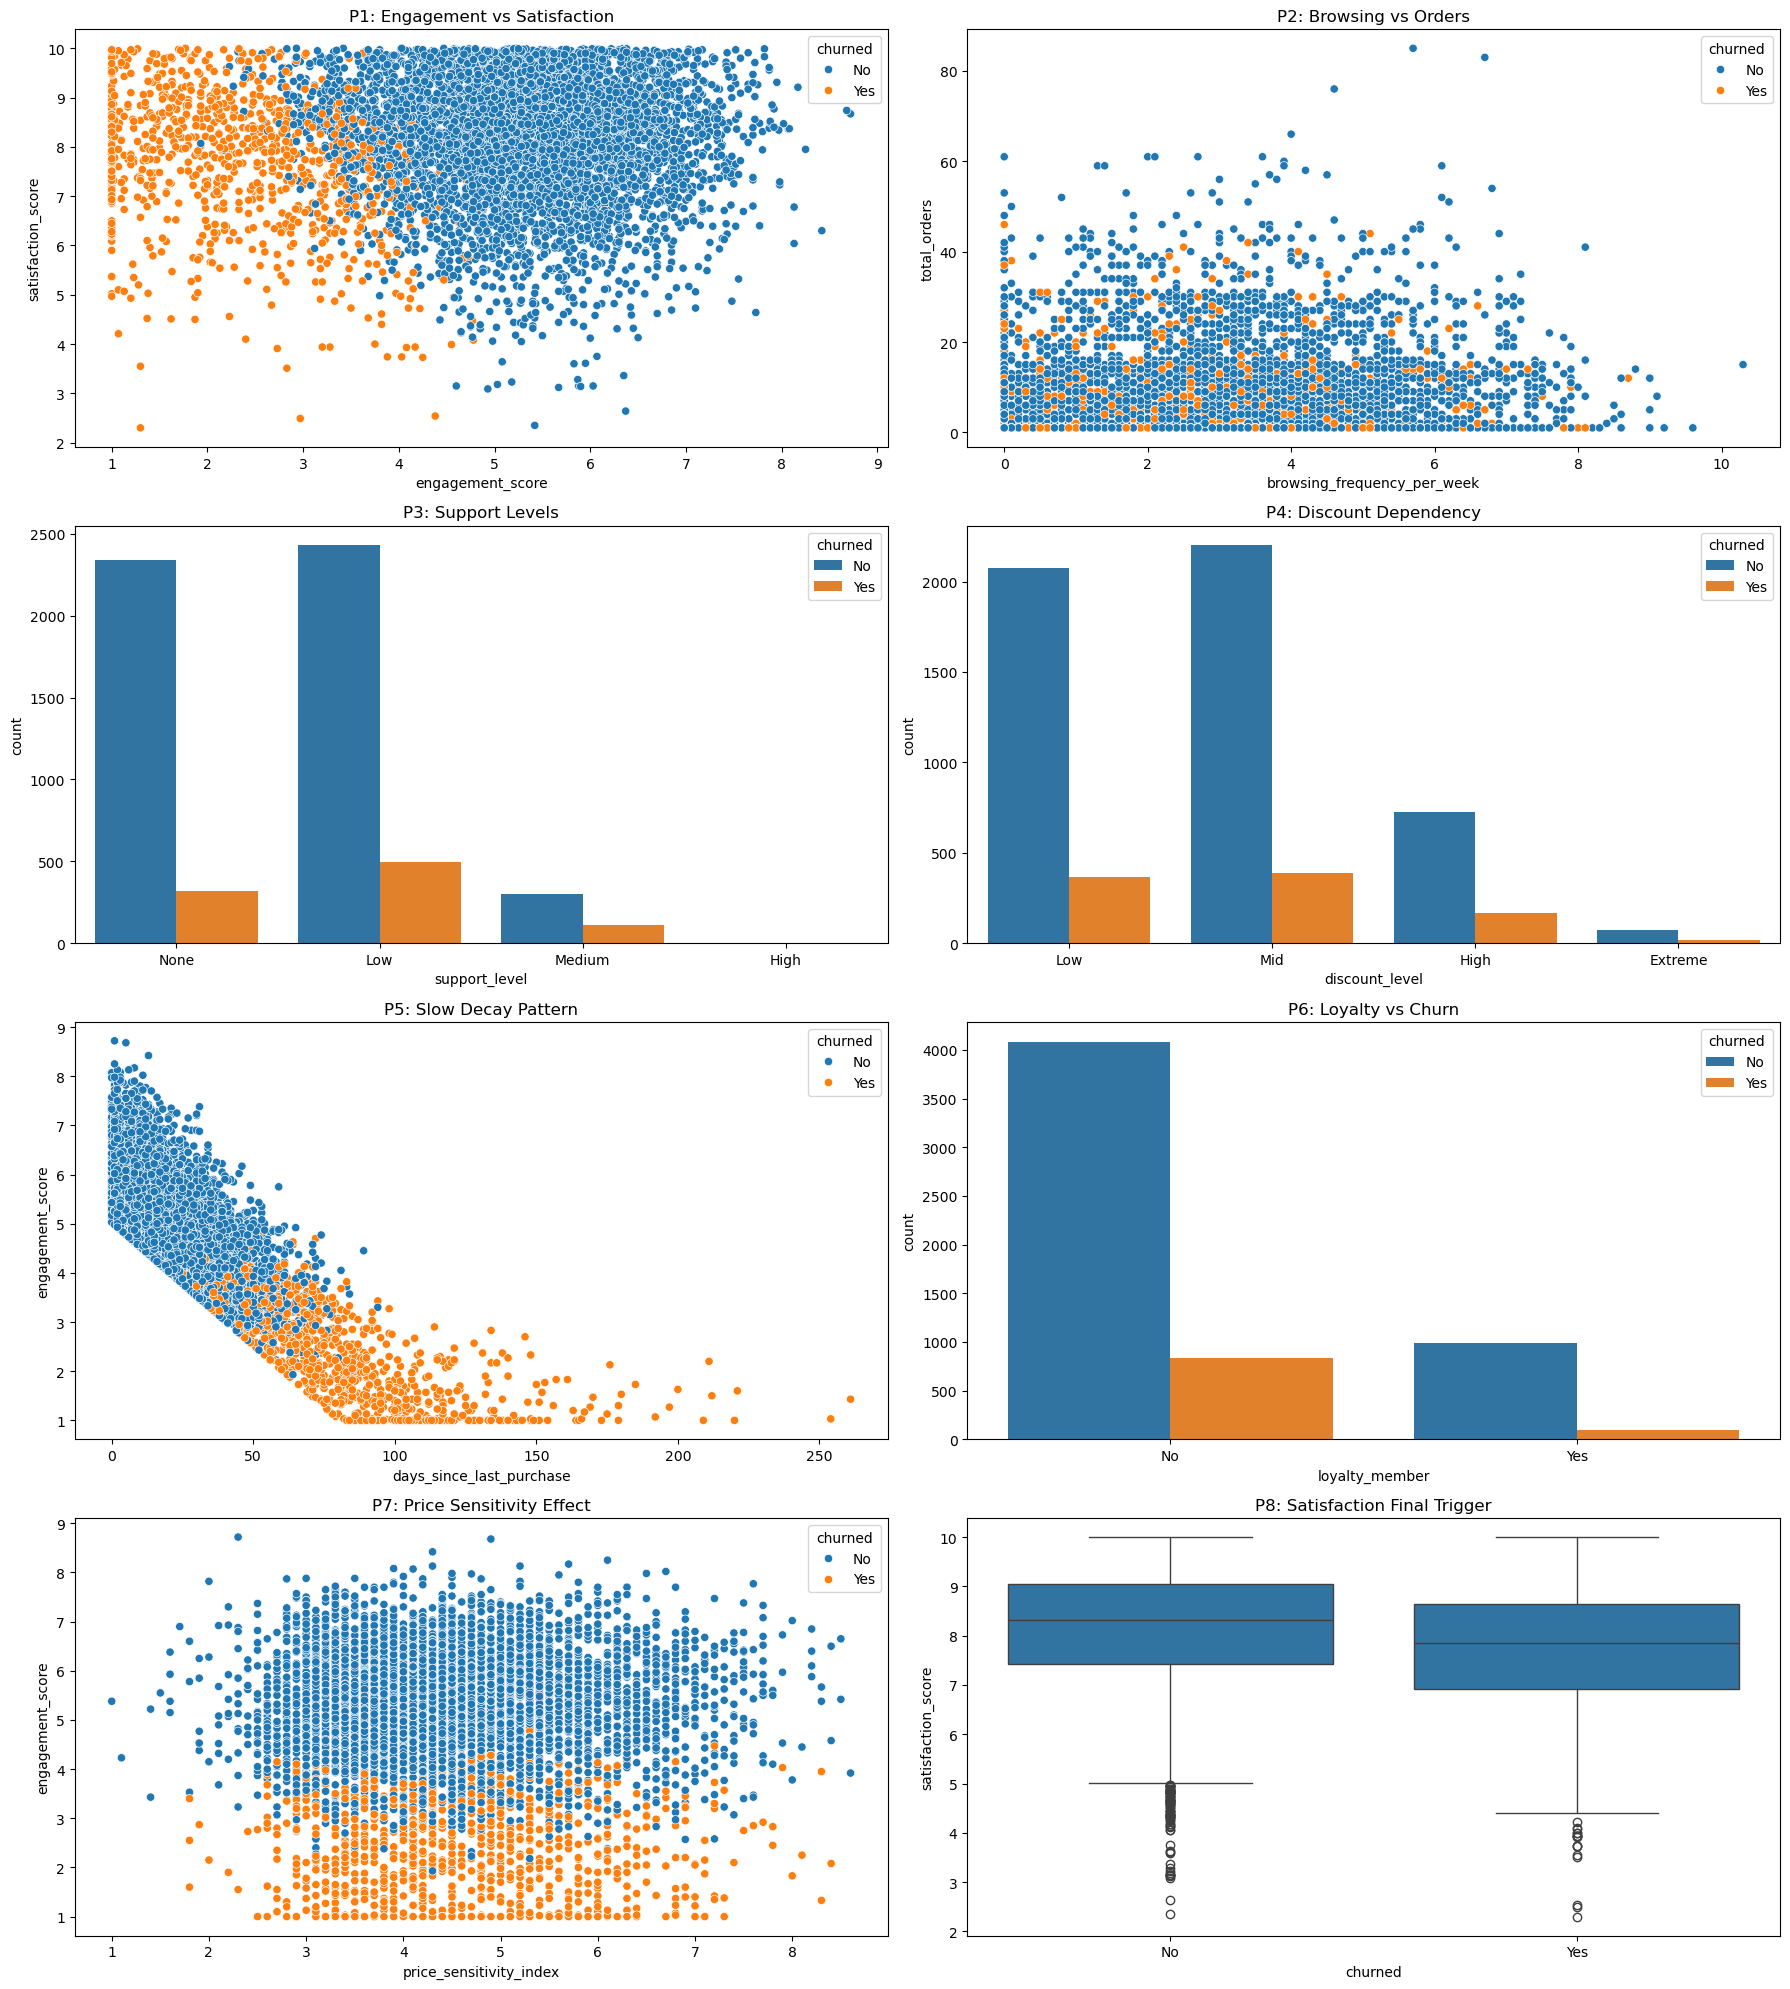

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

# -----------------------------
# 1. Silent Friction
# -----------------------------
sns.scatterplot(
    x='engagement_score',
    y='satisfaction_score',
    hue='churned',
    data=df,
    ax=axes[0]
)
axes[0].set_title("P1: Engagement vs Satisfaction")

# -----------------------------
# 2. Browse Trap
# -----------------------------
sns.scatterplot(
    x='browsing_frequency_per_week',
    y='total_orders',
    hue='churned',
    data=df,
    ax=axes[1]
)
axes[1].set_title("P2: Browsing vs Orders")

# -----------------------------
# 3. Support Paradox
# -----------------------------
df['support_level'] = pd.cut(df['customer_support_tickets'],
                             bins=[-1,0,2,5,10],
                             labels=['None','Low','Medium','High'])

sns.countplot(
    x='support_level',
    hue='churned',
    data=df,
    ax=axes[2]
)
axes[2].set_title("P3: Support Levels")

# -----------------------------
# 4. Discount Addiction
# -----------------------------
df['discount_level'] = pd.cut(df['discount_usage_rate'],
                               bins=4,
                               labels=['Low','Mid','High','Extreme'])

sns.countplot(
    x='discount_level',
    hue='churned',
    data=df,
    ax=axes[3]
)
axes[3].set_title("P4: Discount Dependency")

# -----------------------------
# 5. Slow Decay Churn
# -----------------------------
sns.scatterplot(
    x='days_since_last_purchase',
    y='engagement_score',
    hue='churned',
    data=df,
    ax=axes[4]
)
axes[4].set_title("P5: Slow Decay Pattern")

# -----------------------------
# 6. Loyalty Trap
# -----------------------------
sns.countplot(
    x='loyalty_member',
    hue='churned',
    data=df,
    ax=axes[5]
)
axes[5].set_title("P6: Loyalty vs Churn")

# -----------------------------
# 7. Price Sensitivity
# -----------------------------
sns.scatterplot(
    x='price_sensitivity_index',
    y='engagement_score',
    hue='churned',
    data=df,
    ax=axes[6]
)
axes[6].set_title("P7: Price Sensitivity Effect")

# -----------------------------
# 8. Satisfaction Trigger
# -----------------------------
sns.boxplot(
    x='churned',
    y='satisfaction_score',
    data=df,
    ax=axes[7]
)
axes[7].set_title("P8: Satisfaction Final Trigger")

# -----------------------------
plt.tight_layout()
plt.show()

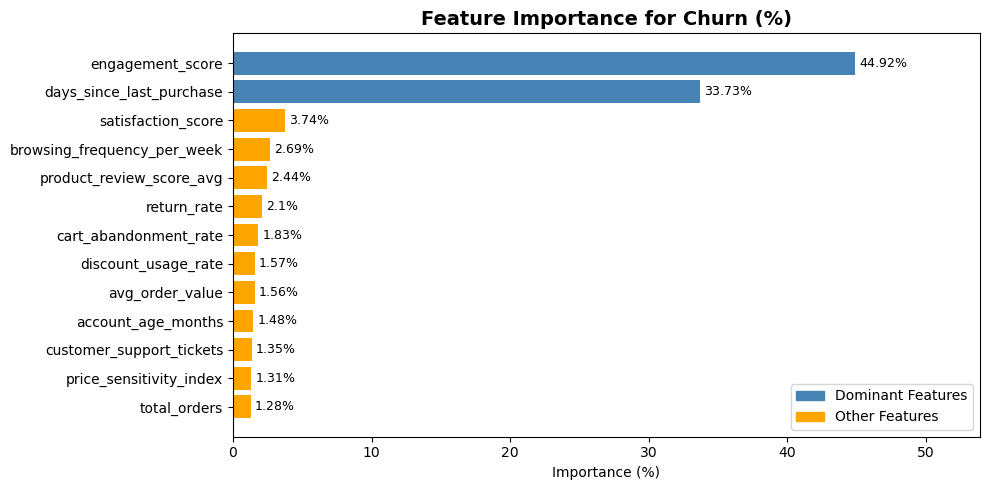

In [43]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

features = [
    'account_age_months', 'avg_order_value', 'total_orders',
    'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
    'customer_support_tickets', 'browsing_frequency_per_week',
    'cart_abandonment_rate', 'product_review_score_avg',
    'engagement_score', 'satisfaction_score',
    'price_sensitivity_index'
]

X = df[features]
y = df['churned']

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Importance → Percentage
imp = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': (imp * 100).round(2)  # ✅ percentage
}).sort_values(by='Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue' if i >= len(feat_imp) - 2 else 'orange'
          for i in range(len(feat_imp))]

bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)

# Values on bars
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=9)  # ✅ % sign

# Legend
legend = [Patch(color='steelblue', label='Dominant Features'),
          Patch(color='orange', label='Other Features')]
ax.legend(handles=legend, loc='lower right')

ax.set_xlim(0, max(feat_imp['Importance']) * 1.2)
ax.set_title("Feature Importance for Churn (%)", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance (%)")
plt.tight_layout()
plt.show()

In [44]:

# Final cleaned dataset save
df.to_csv("cleaned_ecommerce.csv", index=False)
print("File saved successfully!")

File saved successfully!
